=== NA counts per date in interpolated 0-100m profiles ===
(Before any noofNA filtering)

--- Distribution of NAs per profile (0-100m = 101 grid points) ---
# A tibble: 7 × 8
  pigment   n_dates min_NA q25_NA median_NA q75_NA max_NA pct_zero_NA
  <chr>       <int>  <int>  <dbl>     <dbl>  <dbl>  <int>       <dbl>
1 Allo          176      0      0         0      0     45        95.5
2 Fuco          176      0      0         0      0     45        95.5
3 Hex_fuco      176      0      0         0      0     45        95.5
4 Perid         176      0      0         0      0     45        95.5
5 Tot_Chl_a     167      0      0         0      0     98        90.4
6 Tot_Chl_b     176      0      0         0      0     45        95.5
7 Zea           176      0      0         0      0     45        95.5

--- Running with noofNA = 5 ---

--- Running with noofNA = 10 ---

--- Running with noofNA = 15 ---

--- Running with noofNA = 20 ---

--- Running with noofNA = 25 ---

--- Running with noofNA =

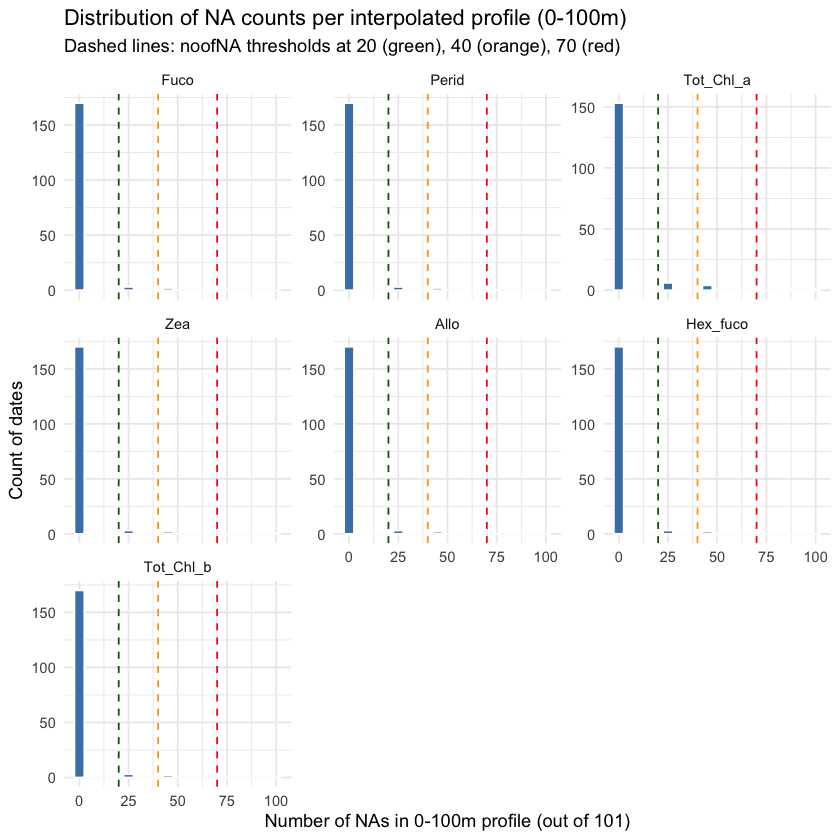

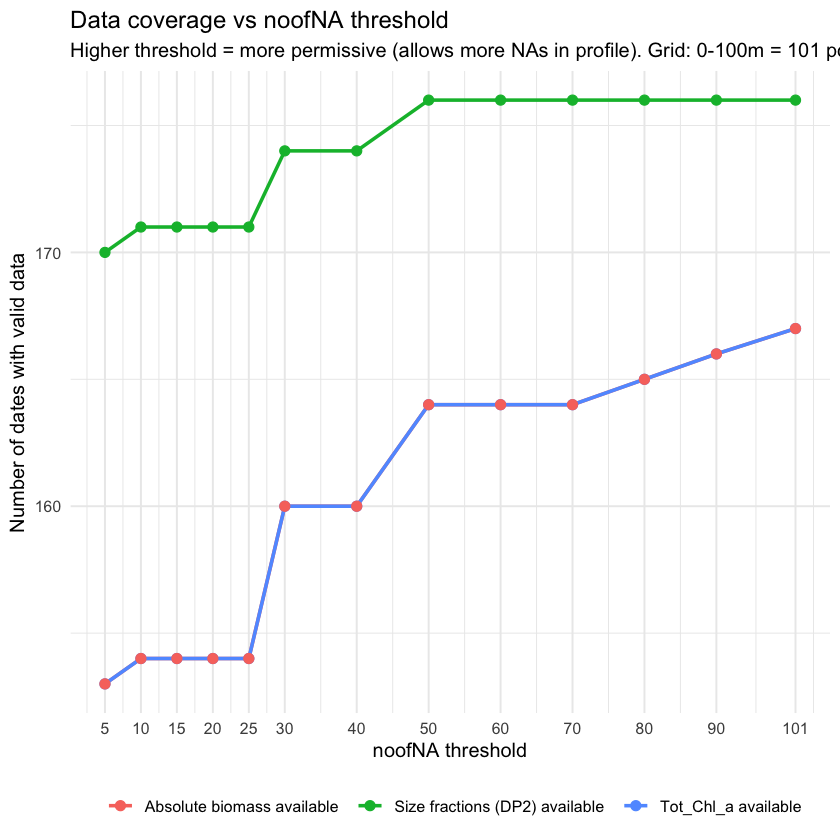


Done. Look for the 'knee' in the coverage curve — the point where
lowering the threshold further causes steep data loss.


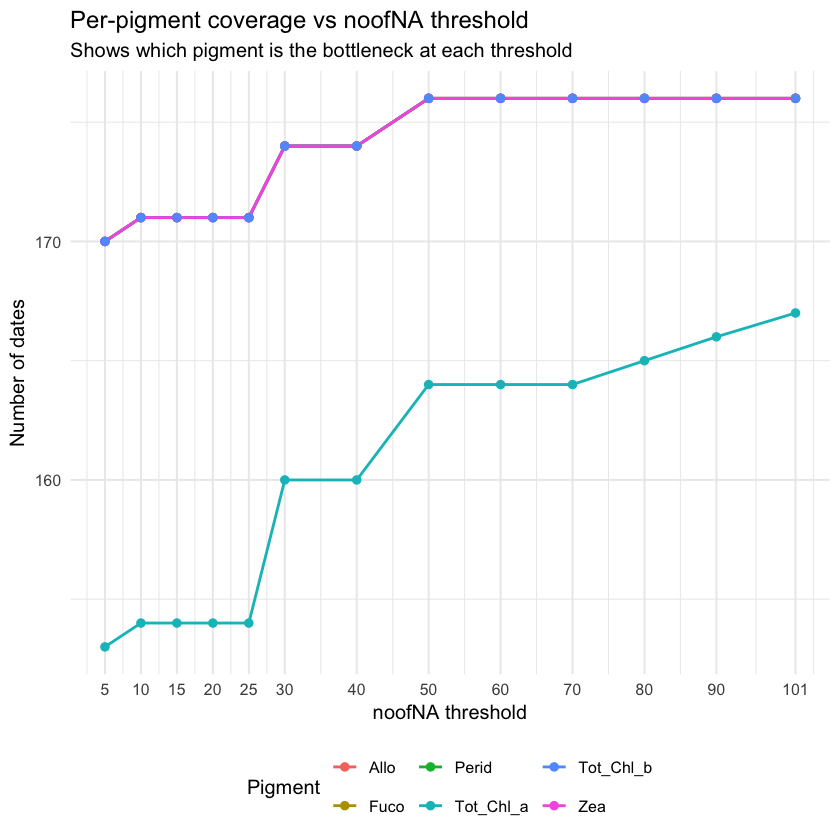

In [3]:
library(tidyverse)

# =============================================================================
# 1. LOAD AND PREPARE (same as processHPLC)
# =============================================================================

hplc_bbrs  <- read.csv("../../BCO-DMO/hplc_bbrs.csv", na.strings = "nd")
hplc_mote  <- read.csv("../../BCO-DMO/hplc_mote.csv", na.strings = "nd")
hplc_hpl   <- read.csv("../../BCO-DMO/hplc_hpl.csv", na.strings = "nd")
hplc_ngsfc <- read.csv("../../BCO-DMO/hplc_ngsfc.csv", na.strings = "nd")

hplc_bbrs$source  <- "BBRS"
hplc_mote$source  <- "MOTE"
hplc_hpl$source   <- "HPL"
hplc_ngsfc$source <- "NGSFC"

pigments <- c("Pras", "Lut", "Fuco", "Perid", "Allo", "But_fuco",
              "Hex_fuco", "Zea", "Tot_Chl_b", "DP", "Tot_Chl_a",
              "TChl", "Chl_c1c2", "Chl_c3")

dp_pigments <- c("Fuco", "Perid", "Allo", "But_fuco", "Hex_fuco", "Zea", "Tot_Chl_b")

fulldat <- c(pigments, "Date", "depth", "source")

HPLC_ds <- rbind(hplc_bbrs[fulldat],
                 hplc_mote[fulldat],
                 hplc_hpl[fulldat],
                 hplc_ngsfc[fulldat])

HPLC_ds$date <- as.Date(as.character(HPLC_ds$Date), format = "%Y%m%d")
HPLC_ds <- HPLC_ds %>% select(-Date)
HPLC_ds[pigments][HPLC_ds[pigments] < 0] <- NA

# Zero-fill DP pigments
HPLC_ds[dp_pigments][is.na(HPLC_ds[dp_pigments])] <- 0

Mesh_HPLC <- HPLC_ds %>%
  select(date, depth, all_of(pigments)) %>%
  group_by(date, depth) %>%
  summarise(across(everything(), ~mean(.x, na.rm = TRUE)), .groups = "drop")

source('../../interpolateData.r')

# =============================================================================
# 2. FIRST: UNDERSTAND THE NA STRUCTURE IN INTERPOLATED PROFILES
#    Before filtering by noofNA, how many NAs do profiles actually have?
# =============================================================================

# Pick a few key pigments to inspect
key_vars <- c("Fuco", "Perid", "Tot_Chl_a", "Zea", "Allo", "Hex_fuco", "Tot_Chl_b")

cat("=== NA counts per date in interpolated 0-100m profiles ===\n")
cat("(Before any noofNA filtering)\n\n")

na_profiles <- list()

for (variable in key_vars) {
  ds_dat <- prepdataframe(Mesh_HPLC, variable)
  ds_int <- interpolateDF(ds_dat, func = 'unesco')
  
  # Count NAs per date within 0-100m
  na_per_date <- ds_int %>%
    filter(depth >= 0 & depth <= 100) %>%
    group_by(date) %>%
    summarise(n_NA = sum(is.na(value_int)), .groups = "drop") %>%
    mutate(pigment = variable)
  
  na_profiles[[variable]] <- na_per_date
}

na_all <- bind_rows(na_profiles)

# Summary: distribution of NA counts per pigment
cat("--- Distribution of NAs per profile (0-100m = 101 grid points) ---\n")
na_summary <- na_all %>%
  group_by(pigment) %>%
  summarise(
    n_dates = n(),
    min_NA = min(n_NA),
    q25_NA = quantile(n_NA, 0.25),
    median_NA = median(n_NA),
    q75_NA = quantile(n_NA, 0.75),
    max_NA = max(n_NA),
    pct_zero_NA = round(100 * mean(n_NA == 0), 1),
    .groups = "drop"
  )
print(na_summary)

# Histogram of NA counts
p_na_hist <- na_all %>%
  mutate(pigment = factor(pigment, levels = key_vars)) %>%
  ggplot(aes(x = n_NA)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  facet_wrap(~pigment, scales = "free_y") +
  geom_vline(xintercept = 20, linetype = "dashed", color = "darkgreen", linewidth = 0.5) +
  geom_vline(xintercept = 40, linetype = "dashed", color = "orange", linewidth = 0.5) +
  geom_vline(xintercept = 70, linetype = "dashed", color = "red", linewidth = 0.5) +
  labs(title = "Distribution of NA counts per interpolated profile (0-100m)",
       subtitle = "Dashed lines: noofNA thresholds at 20 (green), 40 (orange), 70 (red)",
       x = "Number of NAs in 0-100m profile (out of 101)", y = "Count of dates") +
  theme_minimal(base_size = 11)

print(p_na_hist)

# =============================================================================
# 3. SWEEP ACROSS noofNA THRESHOLDS
# =============================================================================

# Key pigments for size fractions + Tot_Chl_a
size_pigments <- c(dp_pigments, "Tot_Chl_a")

thresholds <- c(5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 101)

results <- list()

for (threshold in thresholds) {
  cat(sprintf("\n--- Running with noofNA = %d ---\n", threshold))
  
  temp_store <- list()
  for (variable in size_pigments) {
    temp_store[[variable]] <- interpolateData(
      Mesh_HPLC, variable,
      noofNA = threshold,
      output_type = 'integrated'
    )
    names(temp_store[[variable]])[1] <- variable
  }
  
  df <- temp_store %>% reduce(full_join, by = "date")
  
  df <- df %>% mutate(
    DP2 = 1.41 * Fuco + 1.41 * Perid + 0.60 * Allo +
          0.35 * But_fuco + 1.27 * Hex_fuco + 0.86 * Zea + 1.01 * Tot_Chl_b,
    DP2 = ifelse(DP2 < 0.001, NA, DP2),
    micro = (1.41 * Fuco + 1.41 * Perid) / DP2,
    micro_abs = micro * Tot_Chl_a
  )
  
  results[[as.character(threshold)]] <- data.frame(
    noofNA = threshold,
    n_dates_total = nrow(df),
    n_Tot_Chl_a = sum(!is.na(df$Tot_Chl_a)),
    n_Fuco = sum(!is.na(df$Fuco)),
    n_Perid = sum(!is.na(df$Perid)),
    n_Allo = sum(!is.na(df$Allo)),
    n_Zea = sum(!is.na(df$Zea)),
    n_Tot_Chl_b = sum(!is.na(df$Tot_Chl_b)),
    n_size_fractions = sum(!is.na(df$DP2)),
    n_absolute_biomass = sum(!is.na(df$micro_abs))
  )
}

coverage_df <- bind_rows(results)

cat("\n========================================================\n")
cat("COVERAGE vs noofNA THRESHOLD\n")
cat("========================================================\n")
print(coverage_df)

# =============================================================================
# 4. PLOT: COVERAGE vs THRESHOLD
# =============================================================================

coverage_long <- coverage_df %>%
  select(noofNA, n_Tot_Chl_a, n_size_fractions, n_absolute_biomass) %>%
  pivot_longer(-noofNA, names_to = "metric", values_to = "n_dates") %>%
  mutate(metric = recode(metric,
    "n_Tot_Chl_a"        = "Tot_Chl_a available",
    "n_size_fractions"   = "Size fractions (DP2) available",
    "n_absolute_biomass" = "Absolute biomass available"
  ))

p_coverage <- ggplot(coverage_long, aes(x = noofNA, y = n_dates, color = metric)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.5) +
  scale_x_continuous(breaks = thresholds) +
  labs(title = "Data coverage vs noofNA threshold",
       subtitle = "Higher threshold = more permissive (allows more NAs in profile). Grid: 0-100m = 101 points.",
       x = "noofNA threshold", y = "Number of dates with valid data", color = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_coverage)

# Per-pigment coverage
coverage_pig <- coverage_df %>%
  select(noofNA, starts_with("n_")) %>%
  select(noofNA, n_Fuco, n_Perid, n_Allo, n_Zea, n_Tot_Chl_b, n_Tot_Chl_a) %>%
  pivot_longer(-noofNA, names_to = "pigment", values_to = "n_dates") %>%
  mutate(pigment = str_remove(pigment, "^n_"))

p_pig_coverage <- ggplot(coverage_pig, aes(x = noofNA, y = n_dates, color = pigment)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  scale_x_continuous(breaks = thresholds) +
  labs(title = "Per-pigment coverage vs noofNA threshold",
       subtitle = "Shows which pigment is the bottleneck at each threshold",
       x = "noofNA threshold", y = "Number of dates", color = "Pigment") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_pig_coverage)

cat("\nDone. Look for the 'knee' in the coverage curve — the point where\n")
cat("lowering the threshold further causes steep data loss.\n")